# Certificate mania

## Try to answer the following question using a merge:<br><br>Which colleague has no certificates registered in the SDC database?

#### Hints:
- use `df.merge()`
- use datafiles `sdc_certificaten.csv` and `sdc_personeel.csv`
  * `https://github.com/wortell-smart-learning/python-data-fundamentals/raw/main/data/sdc_certificaten.csv`
  * `https://github.com/wortell-smart-learning/python-data-fundamentals/raw/main/data/sdc_personeel.csv`
- for joining/merging don't use argument `on` but use `left_on` and `right_on`
- you can use `df.unique()` to get the unique nr of values in a column

## 1) Looking at `sdc_personeel.csv`, how many colleagues do you have?

In [40]:
import pandas as pd

certificaten = pd.read_csv("https://github.com/wortell-smart-learning/python-data-fundamentals/raw/main/data/sdc_certificaten.csv")
personeel = pd.read_csv("https://github.com/wortell-smart-learning/python-data-fundamentals/raw/main/data/sdc_personeel.csv")

In [41]:
personeel.shape[0]
#48 colleagus

48

In [42]:
certificaten.head(1)

,id,personeel,certificaat,jaar_behaald
0,92,MoHe,DA-100 - Data Analyst Associate,2021


In [43]:
personeel.head(1)

,id,personeelcode,nr,Voornaam,Achternaam
0,1,BaBo,0,Bart,Beumer


## 2) How many Barts en Jeroens do we have in our company?

In [49]:
personeel[personeel["Voornaam"].isin(["Bart", "Jeroen"])]["Voornaam"].value_counts()

# 3 Barts, 2 Jeroens

,count
Voornaam,
Bart,3
Jeroen,2


## 3) How many certificates are currently listed in `sdc_certificaten.csv` ?

In [50]:
certificaten.shape[0]

#92 in total

92

## 4) Which certificate is listed the most?

In [55]:
certificaten.groupby("certificaat").count().sort_values(by="id", ascending=False).head(5)

,id,personeel,jaar_behaald
certificaat,,,
AZ-900 - Azure Fundamentals,12,12,12
Scrum Master,8,8,8
461 - Querying Microsoft SQL Server 2012/2014,7,7,7
SnowPro Core,7,7,7
DP-200 - Implementing an Azure Data Solution,6,6,6


## 5) Which certificates does colleague `LaSo` have?

In [58]:
certificaten[certificaten['personeel'].isin(["LaSo"])]
#AZ-900, Scrum Master, Certified Data Vault Modeler.

,id,personeel,certificaat,jaar_behaald
5,43,LaSo,AZ-900 - Azure Fundamentals,2020
53,65,LaSo,Certified Data Vault Modeler,2017
61,68,LaSo,Scrum Master,2015


## 6) For figuring out who doesn't have a certificate, we need to merge `sdc_personeel.csv` and `sdc_certifaten.csv`. Think carefully how you join these two. Please create the merge and assign it to a new dataframe variable. Use arguments `left_on` and `right_on` instead on `on` to specify the fields of the two tables to join on.

In [60]:
merged = pd.merge(personeel, certificaten, how='left', left_on= 'personeelcode', right_on= 'personeel')
merged

,id_x,personeelcode,nr,Voornaam,Achternaam,id_y,personeel,certificaat,jaar_behaald
0,1,BaBo,0,Bart,Beumer,1.0,BaBo,Anchor Certifid Modeler,2016.0
1,1,BaBo,0,Bart,Beumer,2.0,BaBo,Prince2 Foundation,2010.0
2,2,MaSt,1,Manfred,Visscher,NaN,NaN,NaN,NaN
3,3,ReRe,2,Thecla,van Breda,89.0,ReRe,Scrum Master,2019.0
4,3,ReRe,2,Thecla,van Breda,88.0,ReRe,461 - Querying Microsoft SQL Server 2012/2014,2016.0
...,...,...,...,...,...,...,...,...,...
105,92,EmOz,51,Justin,Montgomery,NaN,NaN,NaN,NaN
106,93,MoHe,49,Kirsten,Craig,92.0,MoHe,DA-100 - Data Analyst Associate,2021.0
107,95,HiAy,50,Annabella,Ellis,NaN,NaN,NaN,NaN
108,96,BeKo,46,Bertram,Davis,NaN,NaN,NaN,NaN


## 7) So we now have the merged file. Now use for example a `.groupby()` with a `.count()` to figure out who doesn't have any certificates.

In [67]:
merged.groupby("personeelcode").count().query("certificaat == 0")

,id_x,nr,Voornaam,Achternaam,id_y,personeel,certificaat,jaar_behaald
personeelcode,,,,,,,,
AnFa,1,1,1,1,0,0,0,0
BaBe,1,1,1,1,0,0,0,0
BaBl,1,1,1,1,0,0,0,0
BeEc,1,1,1,1,0,0,0,0
BeKo,1,1,1,1,0,0,0,0
CoEg,1,1,1,1,0,0,0,0
DiVe,1,1,1,1,0,0,0,0
EmOz,1,1,1,1,0,0,0,0
GaDu,1,1,1,1,0,0,0,0


## 8) In which year were the most certificates received? Do a `.groupby()` and as an extra: try to create a nice barplot of the result

<Axes: xlabel='jaar_behaald'>

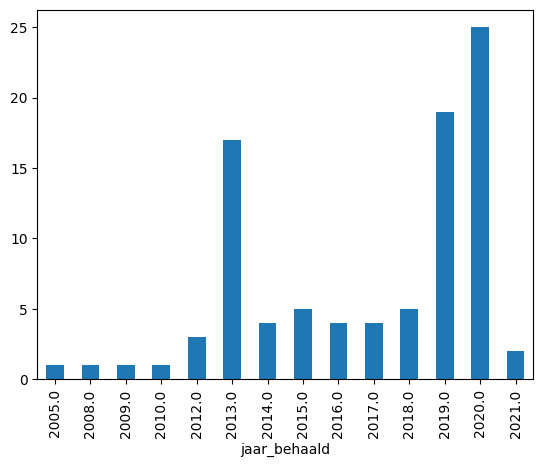

In [75]:
df_plot = merged.groupby("jaar_behaald").count()["certificaat"]
df_plot

df_plot.plot.bar()